BUSINESS UNDERSTANDING
Objective:
Analyze diabetes patient records to identify patient demographics,
hospital stay patterns and readmission trends.

First Five Records
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)    NaN   
1        149190     55629189        Caucasian  Female  [10-20)    NaN   
2         64410     86047875  AfricanAmerican  Female  [20-30)    NaN   
3        500364     82442376        Caucasian    Male  [30-40)    NaN   
4         16680     42519267        Caucasian    Male  [40-50)    NaN   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                  

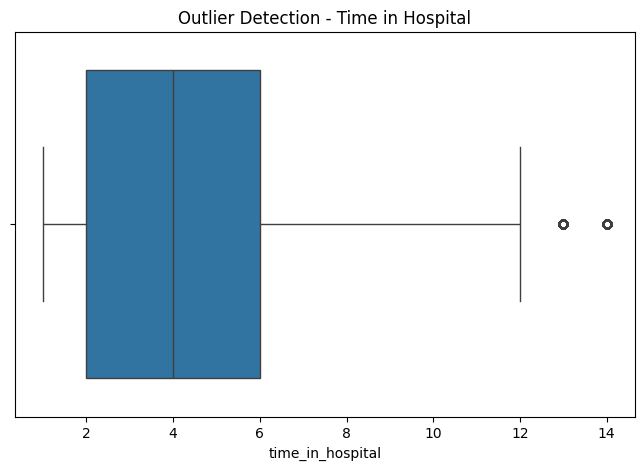

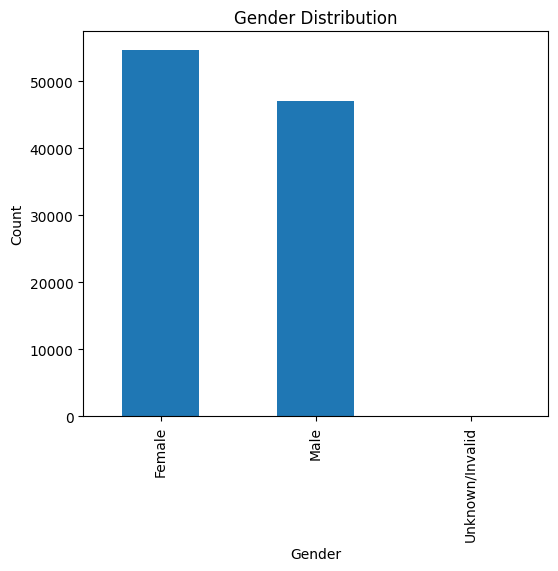

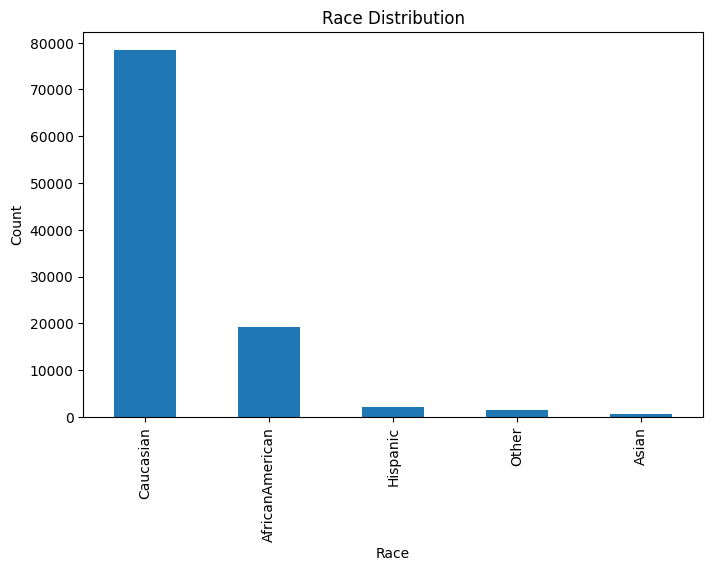

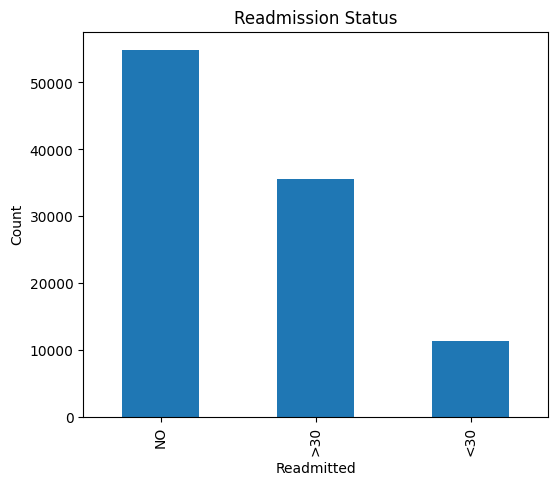

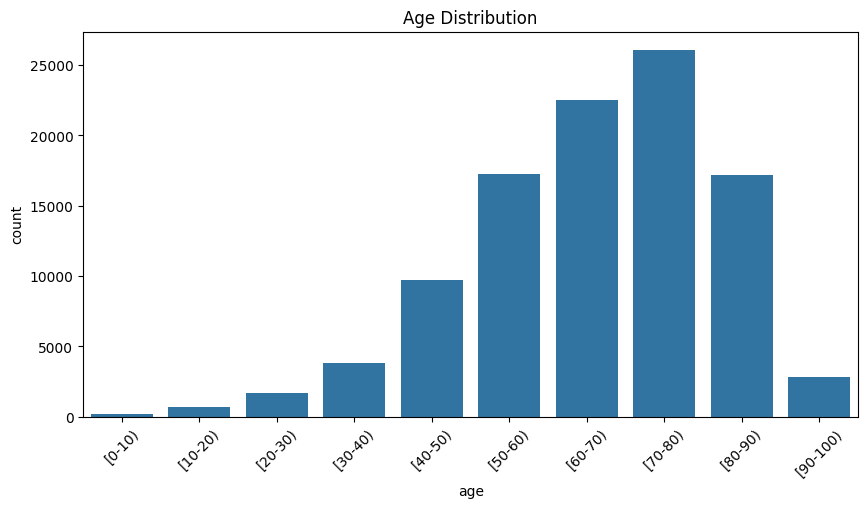

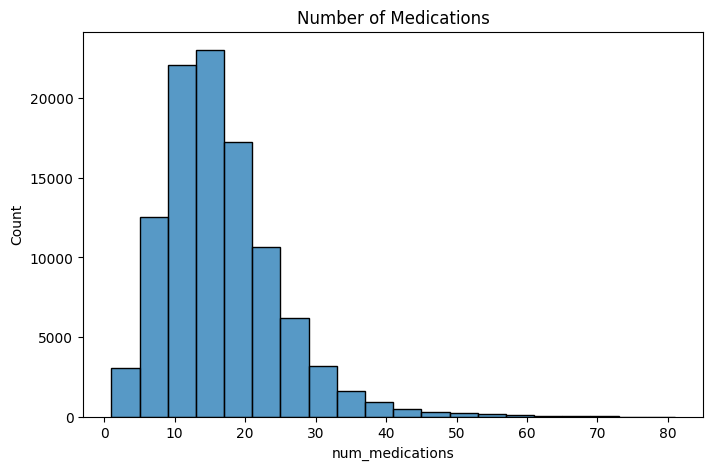

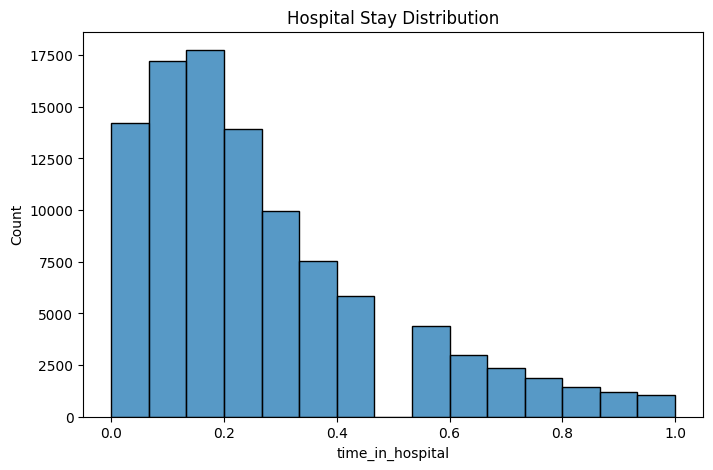

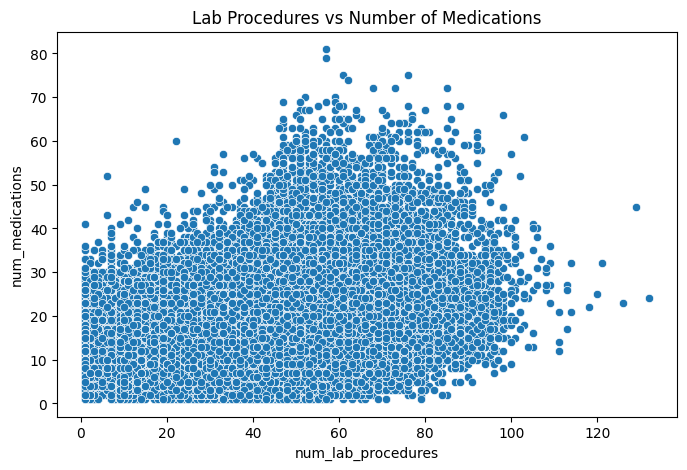

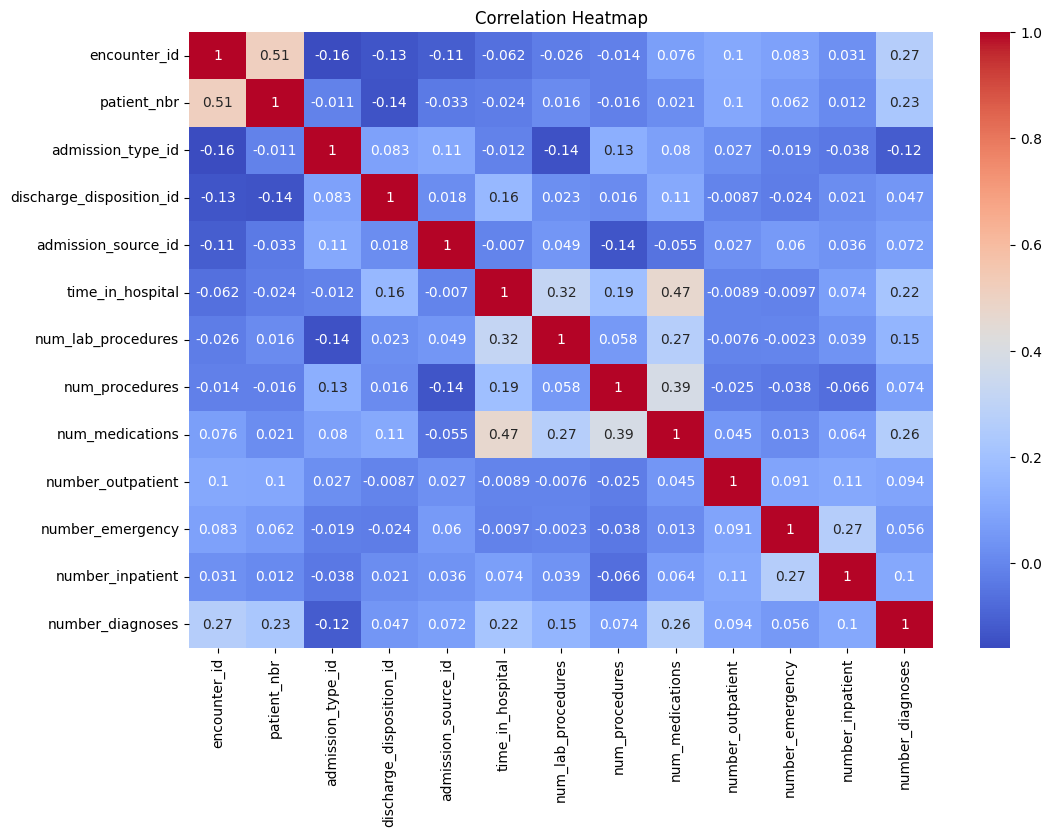

EVALUATION
Business insights generated successfully.
Missing values handled successfully.
Outliers identified.
Visualizations generated successfully.
DEPLOYMENT
The processed dataset can be used for:
- Healthcare Analytics
- Power BI Dashboard
- Data Visualization
- Machine Learning

Cleaned Dataset Saved Successfully.

CRISP-DM Framework Executed Successfully.


In [1]:
# ============================================================
# EXPERIMENT NO: 1
# AIM:
# To perform Exploratory Data Analysis (EDA) and Data Cleaning
# using the CRISP-DM framework on the Diabetes Dataset.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# ============================================================
# CRISP-DM FRAMEWORK
# ============================================================

# ============================================================
# 1. BUSINESS UNDERSTANDING
# ============================================================

print("="*60)
print("BUSINESS UNDERSTANDING")
print("="*60)

print("Objective:")
print("Analyze diabetes patient records to identify patient demographics,")
print("hospital stay patterns and readmission trends.")

# ============================================================
# 2. DATA UNDERSTANDING
# ============================================================

df = pd.read_csv("diabetic_data.csv", na_values="?", low_memory=False)

print("\nFirst Five Records")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

# ============================================================
# 3. DATA PREPARATION
# ============================================================

# Remove columns having large number of missing values

df.drop(columns=[
    "weight",
    "payer_code",
    "medical_specialty",
    "max_glu_serum",
    "A1Cresult"
], inplace=True)

# Fill remaining missing values

df["race"] = df["race"].fillna(df["race"].mode()[0])

df["diag_1"] = df["diag_1"].fillna(df["diag_1"].mode()[0])

df["diag_2"] = df["diag_2"].fillna(df["diag_2"].mode()[0])

df["diag_3"] = df["diag_3"].fillna(df["diag_3"].mode()[0])

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# Outlier Detection

plt.figure(figsize=(8,5))
sns.boxplot(x=df["time_in_hospital"])
plt.title("Outlier Detection - Time in Hospital")
plt.show()

# Normalization

scaler = MinMaxScaler()

df["time_in_hospital"] = scaler.fit_transform(
    df[["time_in_hospital"]]
)

# ============================================================
# 4. MODELING (EDA)
# ============================================================

# Gender Distribution

plt.figure(figsize=(6,5))

df["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

# Race Distribution

plt.figure(figsize=(8,5))

df["race"].value_counts().plot(kind="bar")

plt.title("Race Distribution")

plt.xlabel("Race")

plt.ylabel("Count")

plt.show()

# Readmission Status

plt.figure(figsize=(6,5))

df["readmitted"].value_counts().plot(kind="bar")

plt.title("Readmission Status")

plt.xlabel("Readmitted")

plt.ylabel("Count")

plt.show()

# Age Distribution

plt.figure(figsize=(10,5))

sns.countplot(data=df, x="age")

plt.xticks(rotation=45)

plt.title("Age Distribution")

plt.show()

# Number of Medications

plt.figure(figsize=(8,5))

sns.histplot(df["num_medications"], bins=20)

plt.title("Number of Medications")

plt.show()

# Hospital Stay Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["time_in_hospital"], bins=15)

plt.title("Hospital Stay Distribution")

plt.show()

# Scatter Plot

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="num_lab_procedures",
    y="num_medications"
)

plt.title("Lab Procedures vs Number of Medications")

plt.show()

# Correlation Heatmap

numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# ============================================================
# 5. EVALUATION
# ============================================================

print("="*60)
print("EVALUATION")
print("="*60)

print("Business insights generated successfully.")
print("Missing values handled successfully.")
print("Outliers identified.")
print("Visualizations generated successfully.")

# ============================================================
# 6. DEPLOYMENT
# ============================================================

print("="*60)
print("DEPLOYMENT")
print("="*60)

print("The processed dataset can be used for:")
print("- Healthcare Analytics")
print("- Power BI Dashboard")
print("- Data Visualization")
print("- Machine Learning")

# Save cleaned dataset

df.to_csv("diabetic_data_cleaned.csv", index=False)

print("\nCleaned Dataset Saved Successfully.")

# ============================================================
# RESULT
# ============================================================

print("\nCRISP-DM Framework Executed Successfully.")